# This will be our project

Before running the notebook, set DATA_DIR in the first cell to point to your local dataset folder.

Below the code for K-means clustering, PCA, and necessary preprocessing.

To start, download the dataset and unzip it to a folder named data/ in the Project3 directory. Here is the link: https://drive.google.com/file/d/1Z8IdHF6iOaJ5Ju3LMlaQQGKq4GCqc79b/view?usp=sharing

Contains resampled cells size 32x32x3
Split:

80% train:
    416 dead
    - 1131 live

10% dev:
    52 dead
    - 141 live

10% test:
    52 dead
    - 142 live

In [136]:
import os
import numpy as np
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# DATA_DIR = r"C:\\Users\\elmor\\Documents\\Oslo_sem1\\Machine_Learning\\cells\\cells"
DATA_DIR = r"../data/cells"

def load_split(split):
    images = []
    labels = []

    split_dir = os.path.join(DATA_DIR, split)
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(f"Split directory not found: {split_dir}")

    class_map = {"live": "Live_resized", "dead": "Dead_resized"}
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}

    for label in ["live", "dead"]:
        folder = os.path.join(split_dir, class_map[label])
        if not os.path.isdir(folder):
            raise FileNotFoundError(f"Class folder not found: {folder}")
        files = [f for f in os.listdir(folder)
                 if os.path.isfile(os.path.join(folder, f))
                 and os.path.splitext(f)[1].lower() in valid_exts]
        for fname in sorted(files):
            path = os.path.join(folder, fname)
            img = Image.open(path).convert("RGB")
            if img.size != (32, 32):
                img = img.resize((32, 32))
            images.append(np.array(img))
            labels.append(0 if label == "live" else 1)
    return np.array(images), np.array(labels)

X_train, y_train = load_split("train")
X_dev, y_dev = load_split("dev")
X_test, y_test = load_split("test")

print("Loaded shapes:", X_train.shape, X_dev.shape, X_test.shape)

Loaded shapes: (1547, 32, 32, 3) (193, 32, 32, 3) (194, 32, 32, 3)


In [137]:
# Quick verification: per-split class counts (0=live, 1=dead)
import numpy as np
def _counts(y):
    return {0: int(np.sum(y == 0)), 1: int(np.sum(y == 1))}
print("Train counts:", _counts(y_train))
print("Dev counts:", _counts(y_dev))
print("Test counts:", _counts(y_test))

Train counts: {0: 1131, 1: 416}
Dev counts: {0: 141, 1: 52}
Test counts: {0: 142, 1: 52}


## Preprocessing with PCA



Shape of PCA transformed data: (1547, 300)


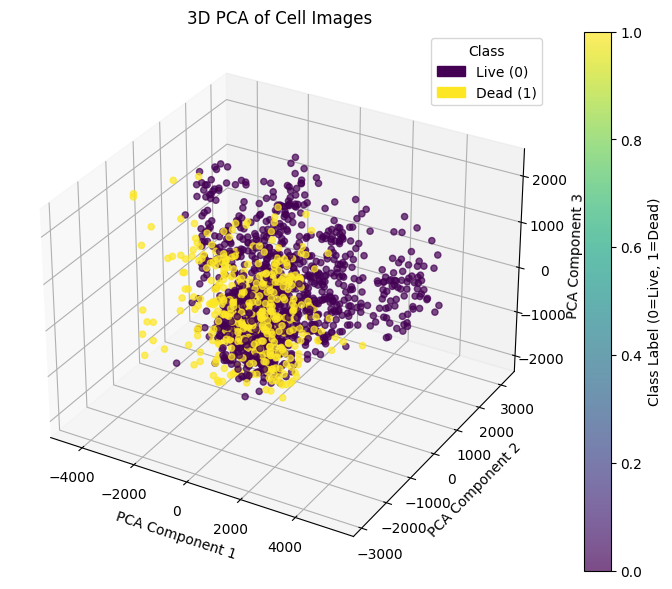

In [ ]:
# Lets take the 3D PCA of the dataset.
X_train_flat = X_train.reshape(X_train.shape[0], -1)
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_flat)

print(f"Shape of PCA transformed data: {X_train_pca.shape}")

# Lets plot the first three PCA components in 3D
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap='viridis', alpha=0.7)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D PCA of Cell Images')

# Add a clear legend (key) for class colors
cmap = plt.cm.viridis
live_patch = mpl.patches.Patch(color=cmap(0.0), label='Live (0)')
dead_patch = mpl.patches.Patch(color=cmap(1.0), label='Dead (1)')
ax.legend(handles=[live_patch, dead_patch], title='Class', loc='best')

fig.colorbar(sc, ax=ax, label='Class Label (0=Live, 1=Dead)')
plt.show()


## K-Means clustering

c:\Users\theod\miniconda3\envs\fys-stk4155\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


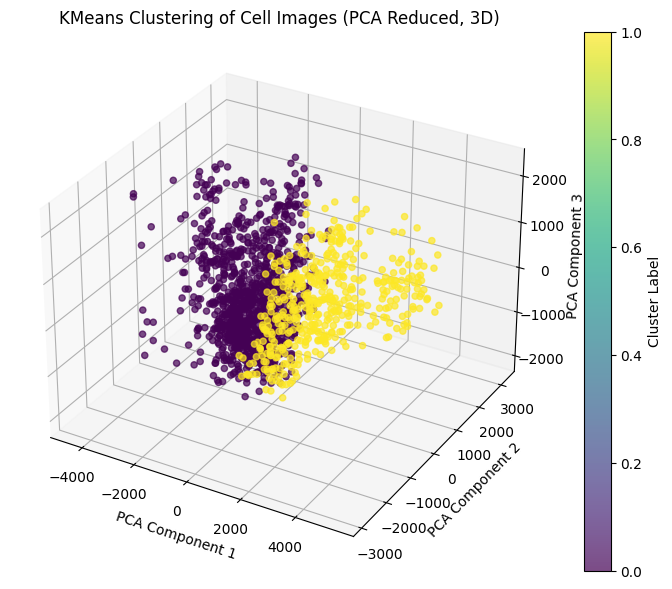

In [139]:
# Now lets cluster the data using KMeans and visualize the clusters. Since we know there will be two classes lets set k=2
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_pca)
y_pred = kmeans.labels_

# Plot the clustered data in 3D (PC1, PC2, PC3)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_pred, cmap='viridis', alpha=0.7)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('KMeans Clustering of Cell Images (PCA Reduced, 3D)')
fig.colorbar(sc, ax=ax, label='Cluster Label')
plt.show()

# Evaluate clustering performance


In [140]:
# Lets use this clustering to create a model which takes the raw images, finds the frst two PCA components, and then assigns the cluster label as the predicted class.
# K-means clustering results in a decision boundary in the PCA-reduced space. We can create a simple model that first reduces the input images to their first two PCA components and then assigns the cluster label based on the K-means clustering.
def pca_kmeans_model(X):
    X_flat = X.reshape(X.shape[0], -1)
    X_pca = pca.transform(X_flat)
    cluster_labels = kmeans.predict(X_pca)
    return cluster_labels

## F1 Score
The F1 score is the harmonic mean of precision and recall:
$$F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$
with
$$\text{precision} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FP}}\quad\text{and}\quad\text{recall} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}}.$$
Here TP, FP, FN denote true positives, false positives, and false negatives.
We chose to use the F1 score because it gives a more vair evaluation metric when there is class imbalance like we see in our dataset. That is, we have more live cell examples than dead cell examples.

In [141]:
# Calculate the accuracy and F1 score for the pca_kmeans_model on the training and the dev sets
from sklearn.metrics import accuracy_score, f1_score
y_train_pred = pca_kmeans_model(X_train)
y_dev_pred = pca_kmeans_model(X_dev)
train_accuracy = accuracy_score(y_train, y_train_pred)
dev_accuracy = accuracy_score(y_dev, y_dev_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Development Accuracy: {dev_accuracy:.4f}")
train_f1 = f1_score(y_train, y_train_pred)
dev_f1 = f1_score(y_dev, y_dev_pred)
print(f"Training F1 Score: {train_f1:.4f}")
print(f"Development F1 Score: {dev_f1:.4f}")

Training Accuracy: 0.6387
Development Accuracy: 0.6736
Training F1 Score: 0.3597
Development F1 Score: 0.3883


# MLP on PCA embedding space

## Neural Network Architecture (MLPClassifier)

**Layer 1 - Input Layer**
- Size: *PCA feature dimension*  
- Receives standardized PCA features.

**Layer 2 - Hidden Layer 1**
- 64 neurons  
- Activation: **ReLU**  
- Regularization: **L2 weight decay** (alpha = 1e-4)

**Layer 3 - Hidden Layer 2**
- 64 neurons  
- Activation: **ReLU**  
- Regularization: **L2 weight decay** (alpha = 1e-4)

**Layer 4 - Output Layer**
- Size: number of classes (`len(np.unique(y_train))`)  
- Activation: **Softmax** (handled internally)


## Training Details
- Optimizer: **Adam** 
- Loss Function: **Cross-entropy**  
- Max Iterations: **300**  
- Batch Size: **200** (sklearn default)  
- Regularization: **L2**, alpha = 1e-4  
- Random Seed: **42**


In [142]:
# Scikit-learn MLP on PCA features (fallback, fast to run)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import time

# Always derive features from the currently fitted `pca`
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_dev_flat   = X_dev.reshape(X_dev.shape[0], -1)
X_train_pca_cur = pca.transform(X_train_flat)
X_dev_pca_cur   = pca.transform(X_dev_flat)
print("Feature dims - train:", X_train_pca_cur.shape[1], "dev:", X_dev_pca_cur.shape[1])

mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(64, 64), activation="relu", max_iter=300, alpha=1e-4, random_state=42))
])

# Measure training time
_t0 = time.time()
mlp_pipe.fit(X_train_pca_cur, y_train)
train_time = time.time() - _t0

# Epoch info from sklearn estimator
epochs_used = getattr(mlp_pipe.named_steps["mlp"], "n_iter_", None)
if epochs_used is not None and epochs_used > 0:
    avg_time_per_epoch = train_time / epochs_used
    print(f"Training time: {train_time:.2f}s | Avg per epoch: {avg_time_per_epoch:.4f}s over {epochs_used} epochs")
else:
    print(f"Training time: {train_time:.2f}s (epoch count unavailable)")

# Predictions
y_train_hat = mlp_pipe.predict(X_train_pca_cur)
y_dev_hat   = mlp_pipe.predict(X_dev_pca_cur)

train_mlp_accuracy = accuracy_score(y_train, y_train_hat)
dev_mlp_accuracy   = accuracy_score(y_dev, y_dev_hat)
train_mlp_f1 = f1_score(y_train, y_train_hat)
dev_mlp_f1   = f1_score(y_dev, y_dev_hat)

print(f"[sklearn] MLP (PCA) - Train Acc: {train_mlp_accuracy:.4f} | Dev Acc: {dev_mlp_accuracy:.4f}")
print(f"[sklearn] MLP (PCA) - Train F1:  {train_mlp_f1:.4f} | Dev F1:  {dev_mlp_f1:.4f}")


Feature dims - train: 300 dev: 300
Training time: 2.55s | Avg per epoch: 0.0499s over 51 epochs
[sklearn] MLP (PCA) - Train Acc: 1.0000 | Dev Acc: 0.9275
[sklearn] MLP (PCA) - Train F1:  1.0000 | Dev F1:  0.8654
Training time: 2.55s | Avg per epoch: 0.0499s over 51 epochs
[sklearn] MLP (PCA) - Train Acc: 1.0000 | Dev Acc: 0.9275
[sklearn] MLP (PCA) - Train F1:  1.0000 | Dev F1:  0.8654


# CNN on raw images

Now we will compare the unsupervised PCA + K-means approach to a well know image classification approach to supervised learning. We will implement a concolutional neural network using the pytorch library to classify the cell images as live or dead.

In [143]:
print("Loaded shapes:", X_train.shape, X_dev.shape, X_test.shape)

Loaded shapes: (1547, 32, 32, 3) (193, 32, 32, 3) (194, 32, 32, 3)


In [144]:
# Created a CNN model using PyTorch
import torch
from torch import nn

class CNN(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        # Input images are 32x32 RGB -> shape [N, 3, 32, 32]
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # -> 16x16
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(4),  # -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate the model and move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=2).to(device)

# Show a short summary-like printout
num_params = sum(p.numel() for p in model.parameters())
print(model.__class__.__name__, f"on {device}")
print(f"Total parameters: {num_params}")

CNN on cpu
Total parameters: 38050


In [145]:
# Train the CNN model
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time

# Prepare data loaders (scale to [0,1])
X_train_t = torch.tensor(X_train).permute(0, 3, 1, 2).float() / 255.0
X_dev_t   = torch.tensor(X_dev).permute(0, 3, 1, 2).float() / 255.0
y_train_t = torch.tensor(y_train).long()
y_dev_t   = torch.tensor(y_dev).long()

train_dataset = TensorDataset(X_train_t, y_train_t)
dev_dataset   = TensorDataset(X_dev_t, y_dev_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=64, shuffle=False)

# Loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Lists to track metrics per epoch
train_losses, dev_losses = [], []
train_accs, dev_accs = [], []
epoch_times = []

# Training loop
epochs = 10
overall_t0 = time.time()
for epoch in range(1, epochs + 1):
    t0 = time.time()

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Dev evaluation
    model.eval()
    dev_correct = 0
    dev_total = 0
    dev_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in dev_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            dev_running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            dev_correct += (preds == yb).sum().item()
            dev_total += yb.size(0)
    dev_acc = dev_correct / dev_total
    dev_loss = dev_running_loss / dev_total

    # Track per-epoch metrics
    train_losses.append(train_loss)
    dev_losses.append(dev_loss)
    train_accs.append(train_acc)
    dev_accs.append(dev_acc)

    # Time for epoch
    dt = time.time() - t0
    epoch_times.append(dt)

    print(f"Epoch {epoch:02d}/{epochs} | Time: {dt:.2f}s | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Dev Loss: {dev_loss:.4f} | Dev Acc: {dev_acc:.4f}")

# Total and average training time
total_train_time = time.time() - overall_t0
avg_epoch_time = total_train_time / epochs if epochs else float('nan')
print(f"Total training time: {total_train_time:.2f}s | Average per epoch: {avg_epoch_time:.2f}s over {epochs} epochs")

Epoch 01/10 | Time: 0.68s | Loss: 0.5723 | Train Acc: 0.7311 | Dev Loss: 0.5153 | Dev Acc: 0.7306
Epoch 02/10 | Time: 0.65s | Loss: 0.4196 | Train Acc: 0.7647 | Dev Loss: 0.2576 | Dev Acc: 0.8860
Epoch 03/10 | Time: 0.72s | Loss: 0.2216 | Train Acc: 0.9089 | Dev Loss: 0.1540 | Dev Acc: 0.9326
Epoch 02/10 | Time: 0.65s | Loss: 0.4196 | Train Acc: 0.7647 | Dev Loss: 0.2576 | Dev Acc: 0.8860
Epoch 03/10 | Time: 0.72s | Loss: 0.2216 | Train Acc: 0.9089 | Dev Loss: 0.1540 | Dev Acc: 0.9326
Epoch 04/10 | Time: 0.66s | Loss: 0.1402 | Train Acc: 0.9476 | Dev Loss: 0.1352 | Dev Acc: 0.9534
Epoch 04/10 | Time: 0.66s | Loss: 0.1402 | Train Acc: 0.9476 | Dev Loss: 0.1352 | Dev Acc: 0.9534
Epoch 05/10 | Time: 0.55s | Loss: 0.1270 | Train Acc: 0.9412 | Dev Loss: 0.0572 | Dev Acc: 1.0000
Epoch 05/10 | Time: 0.55s | Loss: 0.1270 | Train Acc: 0.9412 | Dev Loss: 0.0572 | Dev Acc: 1.0000
Epoch 06/10 | Time: 0.56s | Loss: 0.0810 | Train Acc: 0.9677 | Dev Loss: 0.0387 | Dev Acc: 0.9948
Epoch 06/10 | Time: 

## Loss Curves

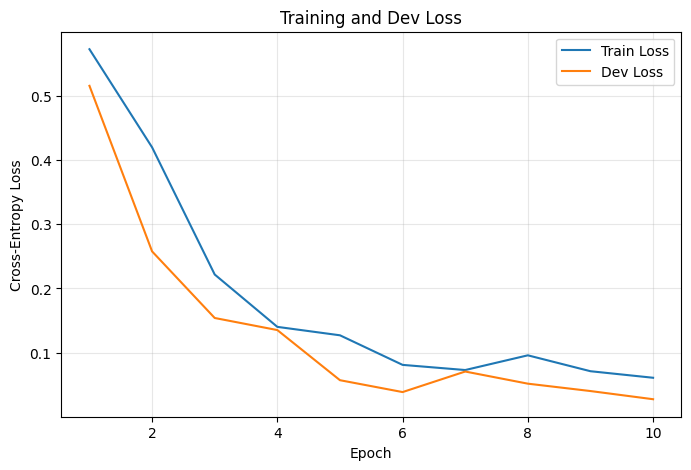

In [146]:
# Plot training and dev loss curves
import matplotlib.pyplot as plt

if len(train_losses) and len(dev_losses):
    epochs_range = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, dev_losses, label='Dev Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.title('Training and Dev Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No recorded losses found. Run the training cell first.")

In [147]:
# Evaluate F1 score on the dev set
from sklearn.metrics import f1_score
import numpy as np

model.eval()
y_true, y_hat = [], []
with torch.no_grad():
    for xb, yb in dev_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_hat.append(preds)
        y_true.append(yb.numpy())

y_true = np.concatenate(y_true)
y_hat = np.concatenate(y_hat)

dev_f1 = f1_score(y_true, y_hat)
print(f"Dev F1 score: {dev_f1:.4f}")

Dev F1 score: 0.9905
